# Two-Dimensional `Receiver`

This notebook provides an empirical demonstration of the expected behavior of a two-dimensional `Receiver`. Its purpose is to make the module's spatial specialization observable in a simple setting in which it can be studied in isolation, rather than to exhaustively validate every implementation detail.

The capability examined is adaptive refinement of the input space. The `Receiver` starts with no prior distinction between different input regions. As stimuli are received, frequently visited regions progressively split into smaller rectangles, while less frequently visited regions remain comparatively coarse. The resulting partition therefore allocates more spatial resolution where inputs occur more often.

## Conceptual Overview

Within Jacinta, a `Receiver` is responsible for receiving input stimuli: the continuous coordinates presented to the processing system. In this two-dimensional example, an input stimulus is a pair of real numbers in a bounded rectangular region. The module does not choose where those stimuli occur. Instead, it observes externally generated inputs and progressively specializes its representation of the regions in which they are received.

The interaction loop is therefore:

1. An external process generates a `ReceiverSample`.
2. `forward()` locates the leaf containing that input and delegates output sampling to its associated `Transmitter`.
3. `backward()` records the visit and eventually refines the corresponding input region when enough evidence has accumulated.

At initialization, the `Receiver` has no evidence that any part of the input space requires more resolution than another. Its tree therefore consists of one rectangle spanning the complete domain. Spatial distinctions emerge only from the frequency with which different regions are visited.

### How the input space is represented

Representing a continuous input space with uniform high resolution would require a fixed discretization, including fine partitions in regions that may rarely or never be observed. The `Receiver` instead specializes `NDSpace`, Jacinta's tree-based representation of continuous space. In two dimensions, every leaf of the tree represents an axis-aligned rectangle, and each incoming coordinate is routed to the leaf whose bounds contain it.

Spatial specialization is driven by visits. Every leaf maintains a hit counter, and once its configured threshold is reached, it attempts to split at its midpoint. A split replaces the original rectangle with four equal children. Subsequent inputs are then distinguished at this finer spatial resolution.

The refinement process is local. Receiving many stimuli in one part of the domain does not force unrelated regions to split. Consequently, regions visited more frequently accumulate hits faster and tend to become smaller, while regions receiving little input can remain represented by larger rectangles. The tree therefore adapts its spatial resolution to the empirical input distribution rather than imposing the same resolution everywhere.

Each receiver region is associated with a `Transmitter`, providing the output-side state that can eventually specialize for that input context. When a receiver leaf splits, each child inherits a copy of the parent's current `Transmitter`. This preserves the state already associated with the broader region while allowing the newly distinguished contexts to evolve independently in subsequent interactions.

### Scope of the demonstration

The sampling function used below is stationary: the relative frequency with which each input region is visited does not change during the run. This isolates the input-side specialization behavior and makes the resulting partition easy to interpret. The notebook therefore demonstrates adaptive spatial refinement *from sequential input exposure*, but it does not test how the module responds when the input distribution itself changes over time.

The associated `Transmitter` is deliberately prevented from refining in this experiment, and every interaction uses zero feedback. Its purpose here is only to satisfy the `Receiver` interaction interface, keeping the experiment focused on how the input partition evolves from visit frequency.

In [1]:
import math
import random
from collections.abc import Callable

import matplotlib.pyplot as plt

from jacinta.processor.evaluators import ZScoreEvaluator
from jacinta.processor.receiver import Receiver, ReceiverSample
from jacinta.processor.transmitter import Transmitter
from jacinta.utils.schedulers import ConstantScheduler

## Configuration

The parameters below are chosen to make the relevant behavior visible within a short, reproducible run. They provide enough interactions for several levels of local refinement to occur, but they should not be interpreted as general-purpose defaults.

The input domain is the half-open square $[-10,10)\times[-10,10)$. The half-open convention follows `NDSpace`: the lower bound of each dimension is included and the upper bound is excluded.

### Spatial refinement

Refinement is controlled by `HITS_RATE = 1000`: after a leaf has received one thousand input stimuli, it attempts to split at its midpoint. A lower threshold would produce finer partitions sooner, based on fewer observations; a higher threshold would keep the representation coarse for longer.

`MIN_WIDTH = 0.001` provides the stopping condition for refinement. A split is rejected if any child would be narrower than this value along any dimension. The limit is intentionally much smaller than the rectangles expected during this experiment, so refinement is determined primarily by visit frequency rather than by reaching the minimum width. `MAX_DEPTH` can therefore remain `None`, since the minimum-width constraint already places a finite bound on the tree depth.

### Scheduler and reproducibility

Hit rate is a depth-dependent parameter in the `Receiver` API. This notebook wraps `HITS_RATE` in a `ConstantScheduler`, so the same setting is used at every depth. Other schedulers can make refinement more or less selective at different depths.

`SEED = 42` makes the externally generated input sequence reproducible, `N_STEPS = 40000` supplies enough interactions for several levels of refinement, and `N_PLOTS = 5` records approximately evenly spaced snapshots of the evolving partition.

In [2]:
MIN_X, MAX_X = -10.0, 10.0
MIN_Y, MAX_Y = -10.0, 10.0
MIN_P, MAX_P = 0.0, 1.0

# hyperparameters
HITS_RATE = 1000
MIN_WIDTH = 0.001
MAX_DEPTH = None
SEED = 42

# simulation parameters
N_STEPS = 40000
N_PLOTS = 5

## Visualization Utilities

The `Receiver` stores its spatial representation implicitly as a tree rather than as a fixed discretization of the input domain. The following helpers expose that structure solely for inspection; they do not participate in routing, sampling, or refinement.

`get_leaves()` recursively traverses the tree and returns its current leaves. Since every leaf represents one active input region, their bounds describe the complete spatial partition maintained by the `Receiver`.

`plot_receiver()` renders each leaf as an axis-aligned rectangle of equal color. Color deliberately carries no additional information: the visualization is intended to show only the spatial specialization itself. Rectangle boundaries therefore correspond directly to divisions in the receiver tree. Regions containing many small rectangles have been refined more strongly, whereas larger rectangles indicate areas that remain comparatively coarse.

`eval_sampling_function()` and `plot_sampling_function()` evaluate the external sampling function over the same domain. The horizontal axes represent the two input coordinates, while relative sampling probability is represented simultaneously by surface height and color. Plotting this function beside the receiver partition makes it possible to compare where input stimuli occur more frequently with where the `Receiver` has allocated additional spatial resolution.

In [3]:
def eval_sampling_function(
    sampling_function: Callable[[float, float], float], x: float, y: float
) -> float:
    """
    Safely evaluate a sampling function for the given values.

    Args:
        sampling_function (Callable[[float, float], float]): The sampling function
            to evaluate.
        x (float): The first value to evaluate the sampling function at.
        y (float): The second value to evaluate the sampling function at.

    Returns:
        float: The result of the sampling function evaluation.
    """
    try:
        p = sampling_function(x, y)
        if not math.isfinite(p):
            p = math.nan
        p = max(min(p, MAX_P), MIN_P)
    except (ArithmeticError, ValueError):
        p = math.nan
    return p

In [4]:
def plot_sampling_function(
    ax: plt.Axes,
    sampling_function: Callable[[float, float], float],
    n_points: int = 100,
    elev: float = 30.0,
    azim: float = 30.0,
) -> None:
    """
    Plot a sampling function.

    Args:
        ax (plt.Axes): The axes to plot on.
        sampling_function (Callable[[float, float], float]): The sampling function
            to plot.
        n_points (int): The number of points to plot per dimension.
            Defaults to 100.
        elev (float): The elevation of the viewing angle.
            Defaults to 30.0.
        azim (float): The azimuth of the viewing angle.
            Defaults to 30.0.
    """
    # evaluate the sampling function
    x_step = (MAX_X - MIN_X) / (n_points - 1)
    y_step = (MAX_Y - MIN_Y) / (n_points - 1)
    x_vals = [MIN_X + idx * x_step for idx in range(n_points)]
    y_vals = [MIN_Y + idx * y_step for idx in range(n_points)]
    x_grid = [x_val for y_val in y_vals for x_val in x_vals]
    y_grid = [y_val for y_val in y_vals for x_val in x_vals]
    p_grid = [
        eval_sampling_function(sampling_function, x_val, y_val)
        for y_val in y_vals
        for x_val in x_vals
    ]
    # build the mesh triangles
    triangles = []
    for row in range(n_points - 1):
        for col in range(n_points - 1):
            # build the mesh cell
            top_left = row * n_points + col
            top_right = top_left + 1
            bottom_left = (row + 1) * n_points + col
            bottom_right = bottom_left + 1
            # split the cell into two triangles
            triangles.append([top_left, top_right, bottom_right])
            triangles.append([top_left, bottom_right, bottom_left])
    # plot the sampling function
    ax.plot_trisurf(
        x_grid,
        y_grid,
        p_grid,
        triangles=triangles,
        cmap="summer",
        antialiased=False,
    )
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlim(MIN_X, MAX_X)
    ax.set_ylim(MIN_Y, MAX_Y)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.zaxis.set_rotate_label(False)
    ax.set_zlabel("p", rotation=90)
    ax.set_title(f"Sampling Function (elev={elev}, azim={azim})")
    ax.grid(visible=True)
    return

In [5]:
def get_leaves(receiver: Receiver) -> list[Receiver]:
    """
    Get the receiver leaves.

    Args:
        receiver (Receiver): The receiver to get the leaves of.

    Returns:
        list[Receiver]: A list containing the receiver leaves.
    """
    # check if the receiver is a leaf
    if receiver.is_leaf:
        leaves = [receiver]
    # otherwise, recursively get its leaves
    else:
        leaves = []
        for child in receiver.children:
            child_leaves = get_leaves(child)
            leaves.extend(child_leaves)
    return leaves

In [6]:
def plot_receiver(ax: plt.Axes, receiver: Receiver) -> None:
    """
    Plot the spatial specialization of a receiver.

    Args:
        ax (plt.Axes): The axes to plot on.
        receiver (Receiver): The receiver to plot.
    """
    # get the receiver leaves
    leaves = get_leaves(receiver)
    # sort the leaves by their lower bounds
    leaves.sort(key=lambda leaf: (leaf.bounds[0][0], leaf.bounds[1][0]))
    # plot each receiver leaf
    for leaf in leaves:
        x_lower, x_upper = leaf.bounds[0]
        y_lower, y_upper = leaf.bounds[1]
        ax.fill(
            [x_lower, x_upper, x_upper, x_lower],
            [y_lower, y_lower, y_upper, y_upper],
            color="C0",
            alpha=0.3,
        )
        ax.vlines([x_lower, x_upper], ymin=y_lower, ymax=y_upper)
        ax.hlines([y_lower, y_upper], xmin=x_lower, xmax=x_upper)
    # plot the receiver
    ax.set_xlim(MIN_X, MAX_X)
    ax.set_ylim(MIN_Y, MAX_Y)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Receiver Spatial Specialization")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(visible=True, alpha=0.3)
    return

## Sampling Function

The `Receiver` does not choose its own inputs, so this playground needs an external process that generates input stimuli. In this controlled setting, that process is represented by a stationary sampling function: coordinates are drawn repeatedly from the same underlying distribution. This makes the evolution of the receiver's spatial specialization easier to interpret.

The sampling function combines three smooth peaks with different relative magnitudes and spatial extents. Its global maximum is approximately 1.0 near $(x,y)=(-3.0,3.5)$; lower local maxima of approximately 0.70 and 0.45 occur near $(-6.0,-4.5)$ and $(5.5,-3.5)$, respectively. The distribution is deliberately nonuniform and multimodal. A uniform distribution would tend to refine the input space evenly, whereas spatially separated regions with different sampling frequencies make it possible to observe whether the `Receiver` allocates finer spatial resolution where stimuli occur more often.

The plotted surface is shown for explanation, but it is not available to the `Receiver`. The module receives neither the sampling function nor the relative probability associated with each coordinate. At each interaction it observes only the input stimulus that was sampled. The resulting spatial specialization is therefore driven entirely by the frequency with which different regions of the input space are encountered.

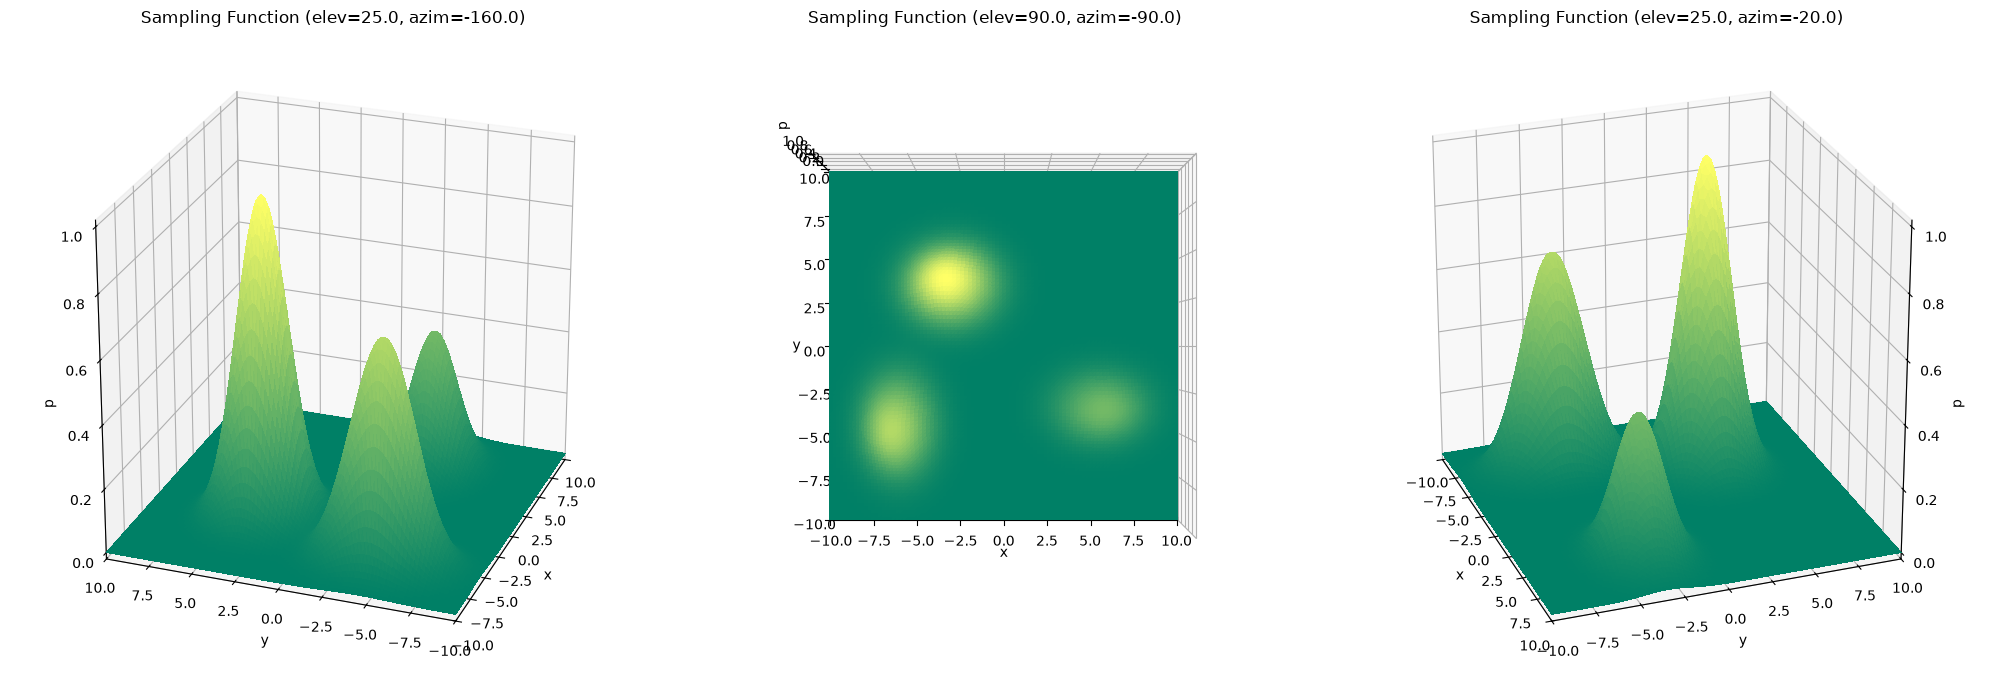

In [7]:
def sampling_function(x: float, y: float) -> float:
    """
    Sampling function.

    Args:
        x (float): The first value to evaluate the sampling function at.
        y (float): The second value to evaluate the sampling function at.

    Returns:
        float: The relative probability of sampling the point.
    """
    p = (
        1.00 * math.exp(-0.5 * (((x + 3.0) / 1.6) ** 2 + ((y - 3.5) / 1.4) ** 2))
        + 0.70 * math.exp(-0.5 * (((x + 6.0) / 1.3) ** 2 + ((y + 4.5) / 1.8) ** 2))
        + 0.45 * math.exp(-0.5 * (((x - 5.5) / 1.7) ** 2 + ((y + 3.5) / 1.3) ** 2))
    )
    return p


# plot the sampling function
fig, ax = plt.subplots(ncols=3, figsize=(20, 7), subplot_kw={"projection": "3d"})
plot_sampling_function(ax[0], sampling_function, elev=25.0, azim=-160.0)
plot_sampling_function(ax[1], sampling_function, elev=90.0, azim=-90.0)
plot_sampling_function(ax[2], sampling_function, elev=25.0, azim=-20.0)
# adjust the aspect ratio of each plot
for axis in ax:
    axis.set_box_aspect((1, 1, 1), zoom=0.95)
fig.tight_layout()
plt.show()

In [8]:
def get_sampling_function_max(
    sampling_function: Callable[[float, float], float],
    n_points: int = 100,
) -> float:
    """
    Approximate the maximum of a sampling function.

    Args:
        sampling_function (Callable[[float, float], float]): The sampling function
            to evaluate.
        n_points (int): The number of points to evaluate per dimension.
            Defaults to 100.

    Returns:
        float: The approximate maximum of the sampling function.
    """
    # evaluate the sampling function
    x_step = (MAX_X - MIN_X) / (n_points - 1)
    y_step = (MAX_Y - MIN_Y) / (n_points - 1)
    x_vals = [MIN_X + idx * x_step for idx in range(n_points)]
    y_vals = [MIN_Y + idx * y_step for idx in range(n_points)]
    p_vals = [
        eval_sampling_function(sampling_function, x_val, y_val)
        for y_val in y_vals
        for x_val in x_vals
    ]
    # get the sampling function maximum
    max_p = max(p_vals)
    return max_p

In [9]:
def sample(
    sampling_function: Callable[[float, float], float],
    max_p: float,
    rng: random.Random,
) -> ReceiverSample:
    """
    Sample from a sampling function.

    Args:
        sampling_function (Callable[[float, float], float]): The sampling function.
        max_p (float): The upper bound used for rejection sampling.
        rng (random.Random): The random number generator used for sampling.

    Returns:
        ReceiverSample: The sampled input.
    """
    # sample using rejection sampling
    while True:
        x = rng.uniform(MIN_X, MAX_X)
        y = rng.uniform(MIN_Y, MAX_Y)
        p = rng.uniform(MIN_P, max_p)
        if p <= eval_sampling_function(sampling_function, x, y):
            break
    # generate the receiver sample
    rsample = ReceiverSample(
        coordinates=(x, y),
    )
    return rsample

## Simulation

The `Receiver` is now exposed to repeated input stimuli drawn from the sampling function. It begins as a single leaf spanning the complete region, so every coordinate initially belongs to the same input region. The random seed makes the sampled sequence reproducible.

Each iteration executes the complete interaction cycle:

1. `sample()` draws an input coordinate from the stationary sampling distribution.
2. `forward(bias=0.0)` locates the receiver leaf containing that coordinate and samples from its associated `Transmitter`.
3. `backward()` records the visit and refines the corresponding receiver region whenever its hit threshold is reached.

The associated `Transmitter` cannot refine in this experiment, and the feedback passed to `backward()` is always zero, so it plays no active role beyond satisfying the interaction interface. The changes visible in the receiver plot are driven only by the frequency with which different parts of the input space are visited. Each rectangular boundary marks a division between receiver leaves, so smaller rectangles indicate greater spatial specialization.

### Reading the snapshots

The first snapshot contains a single region because only one interaction has occurred and the root has not yet reached its split threshold.

By step 10,001, the receiver has undergone several coarse refinements. The strongest specialization has already begun in the upper-left region containing the dominant peak near $(-3.0,3.5)$, while the lower-left and lower-right parts of the domain have also begun to separate according to the secondary sampling modes.

By step 20,001, the relationship between sampling frequency and spatial resolution is substantially clearer. Multiple successive splits have accumulated around the dominant peak, producing a cluster of small rectangles in the upper-left part of the domain. Additional refinement is visible around the secondary peak near $(-6.0,-4.5)$ and the weaker peak near $(5.5,-3.5)$, while low-frequency regions remain represented by much larger rectangles.

By step 30,000, this trend continues rather than introducing a new behavior. Further splits concentrate around the same three high-frequency regions, increasing the contrast between the locally refined areas and the comparatively coarse remainder of the domain.

By the final snapshot, the partition is clearly nonuniform. The finest concentration of rectangles appears around the dominant peak near $(-3.0,3.5)$, followed by the secondary regions near $(-6.0,-4.5)$ and $(5.5,-3.5)$. Large parts of the domain in which the sampling probability is low remain comparatively coarse. The sequence therefore shows the intended behavior of the `Receiver`: spatial resolution progressively concentrates where input stimuli are encountered more frequently.

In [10]:
# initialize a 1D Transmitter
transmitter = Transmitter(
    bounds=((-10.0, 10.0),),
    evaluator=ZScoreEvaluator(0.001, 0.001),
    bias_scale_scheduler=ConstantScheduler(value=10.0),
    learning_rate_scheduler=ConstantScheduler(value=0.001),
    hits_rate_scheduler=ConstantScheduler(value=1000),
    min_width=1,
    max_depth=0,
    seed=42,
)

In [11]:
# initialize a 2D Receiver
receiver = Receiver(
    bounds=((MIN_X, MAX_X), (MIN_Y, MAX_Y)),
    transmitter=transmitter,
    hits_rate_scheduler=ConstantScheduler(value=HITS_RATE),
    min_width=MIN_WIDTH,
    max_depth=MAX_DEPTH,
)

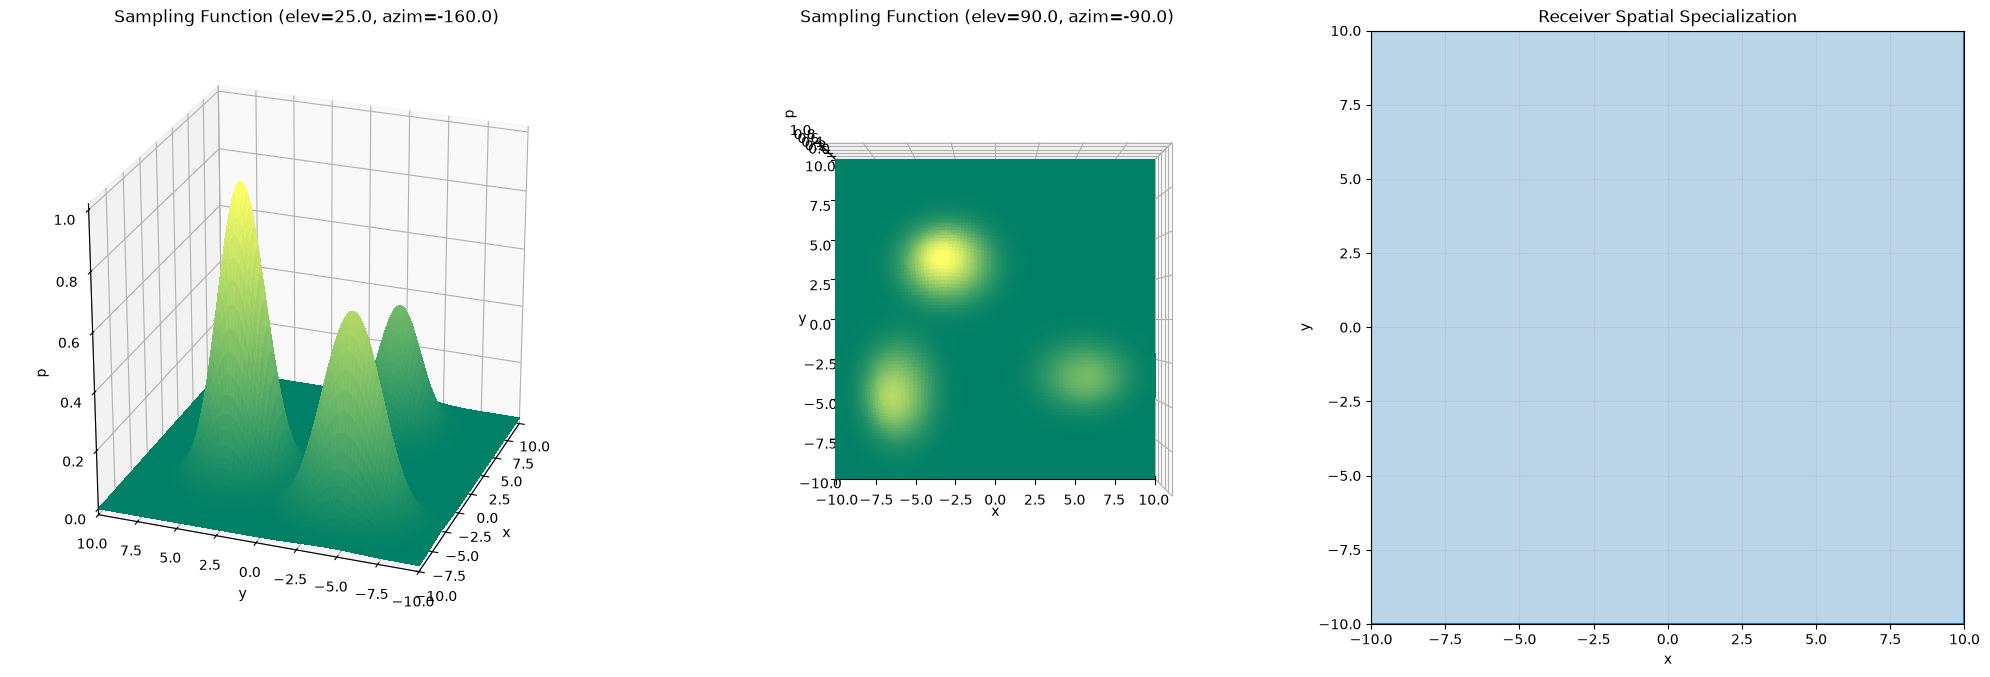

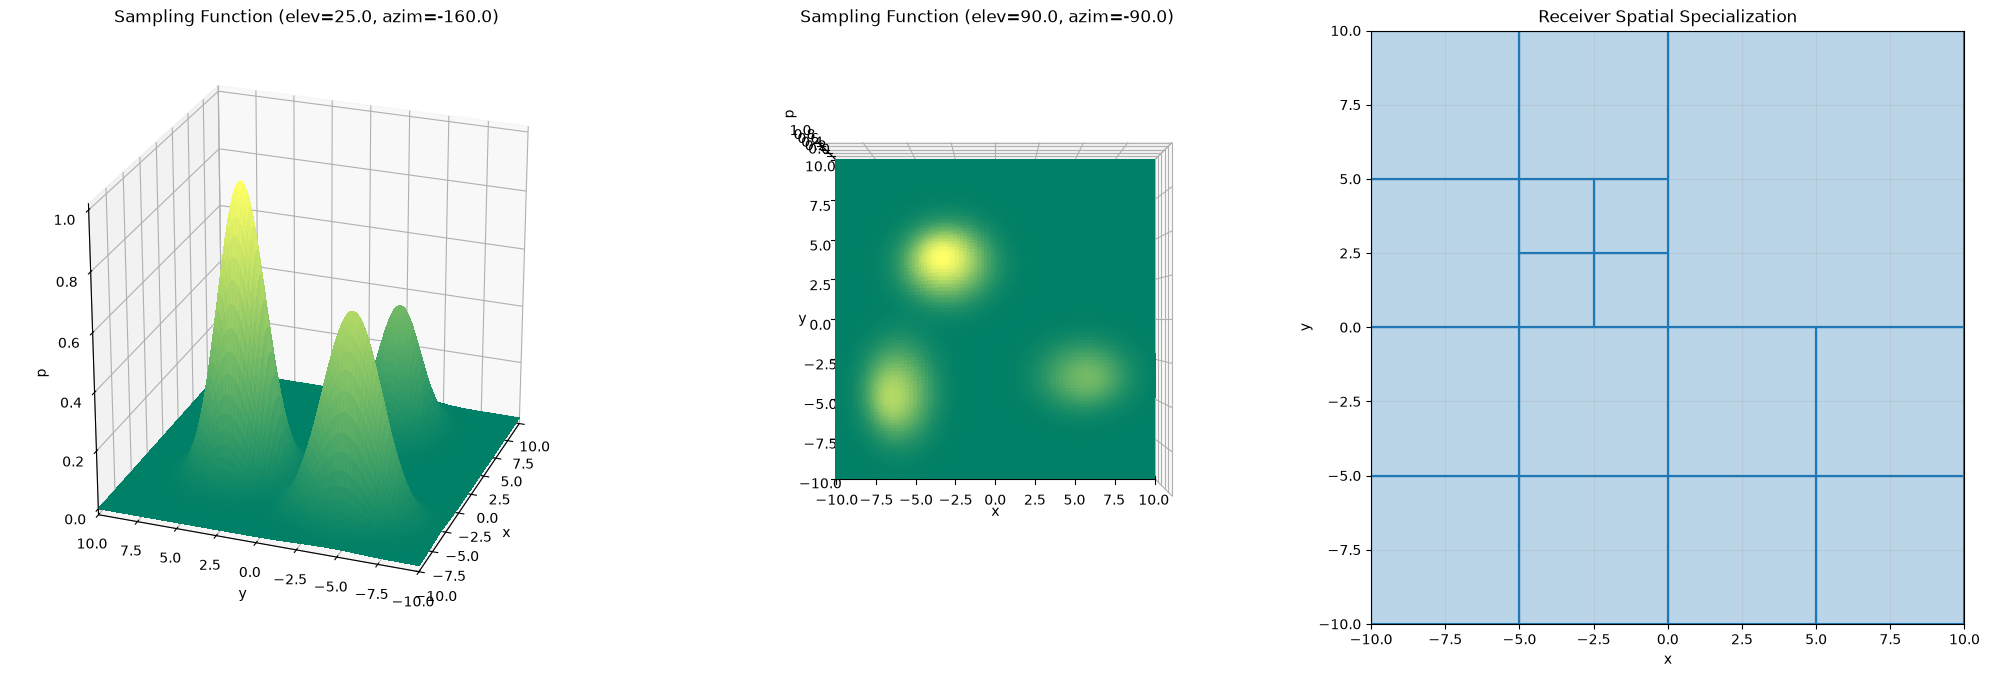

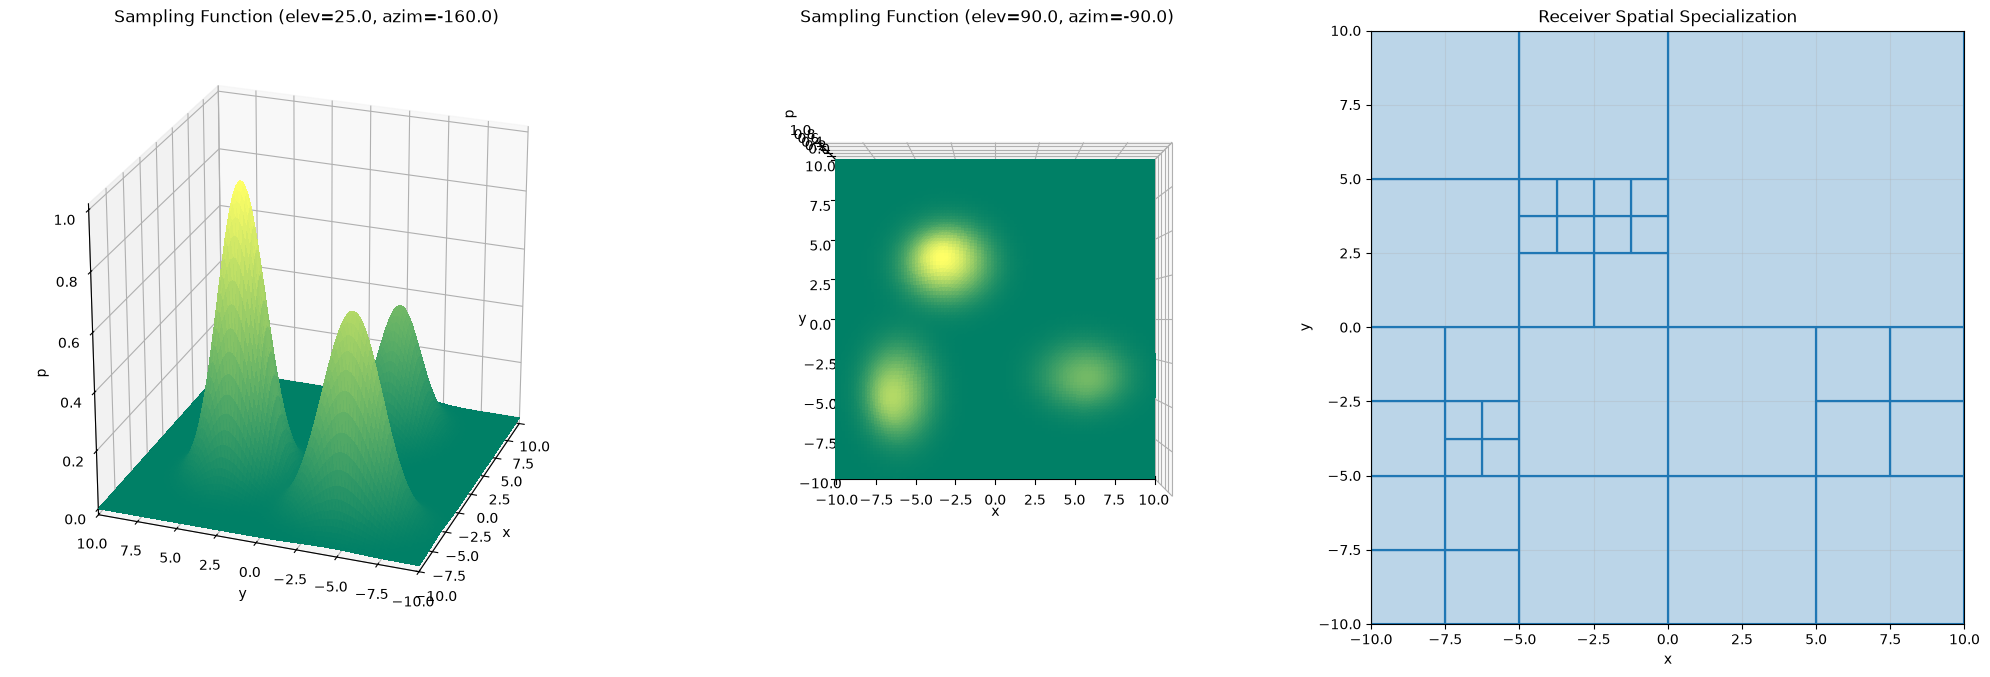

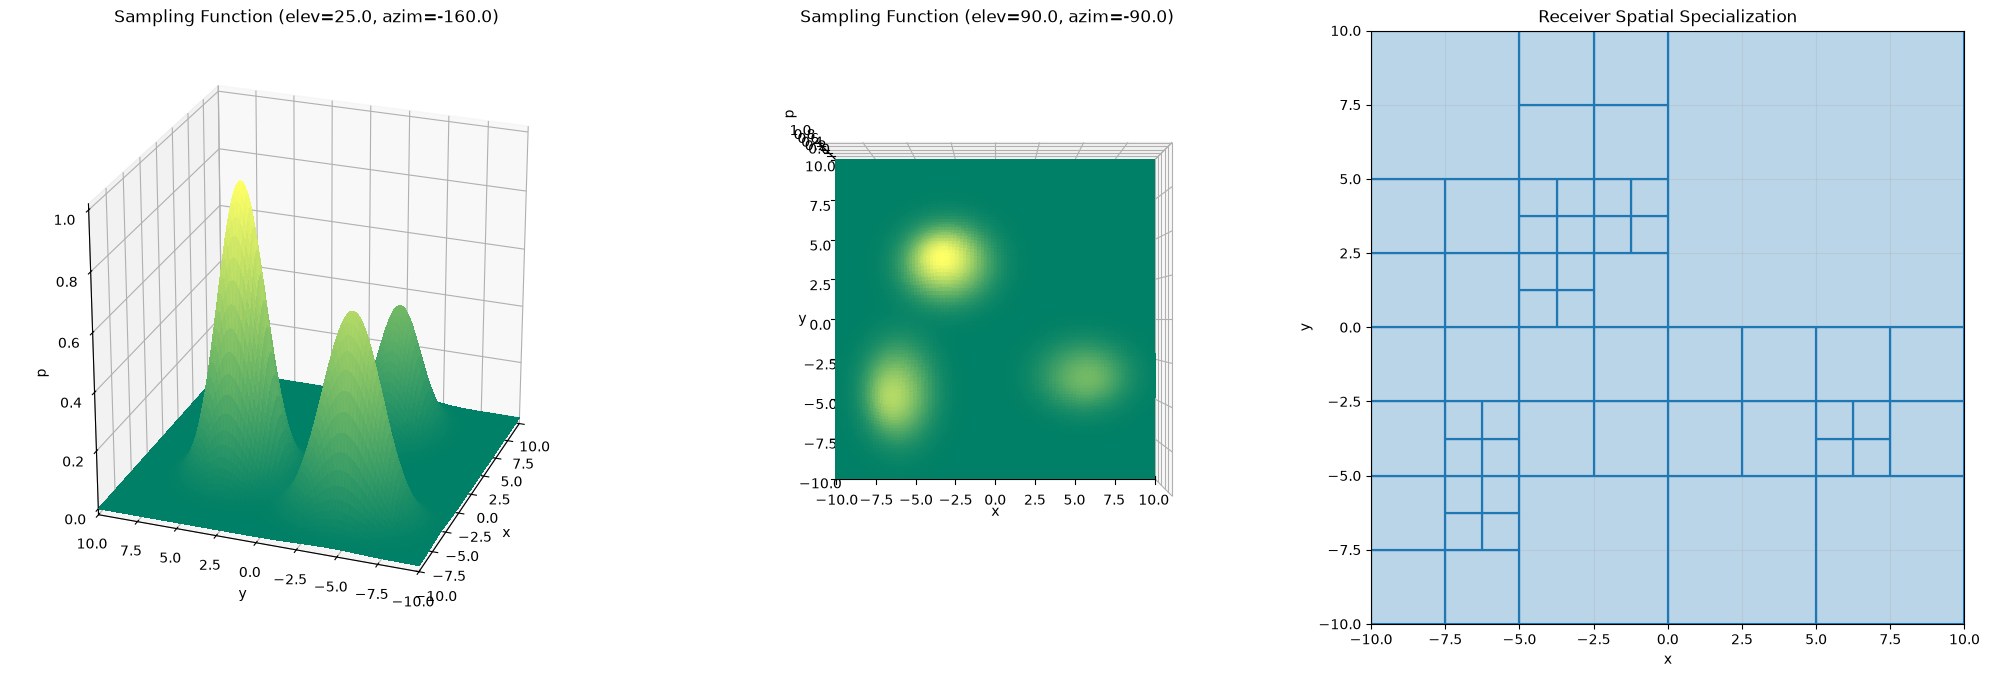

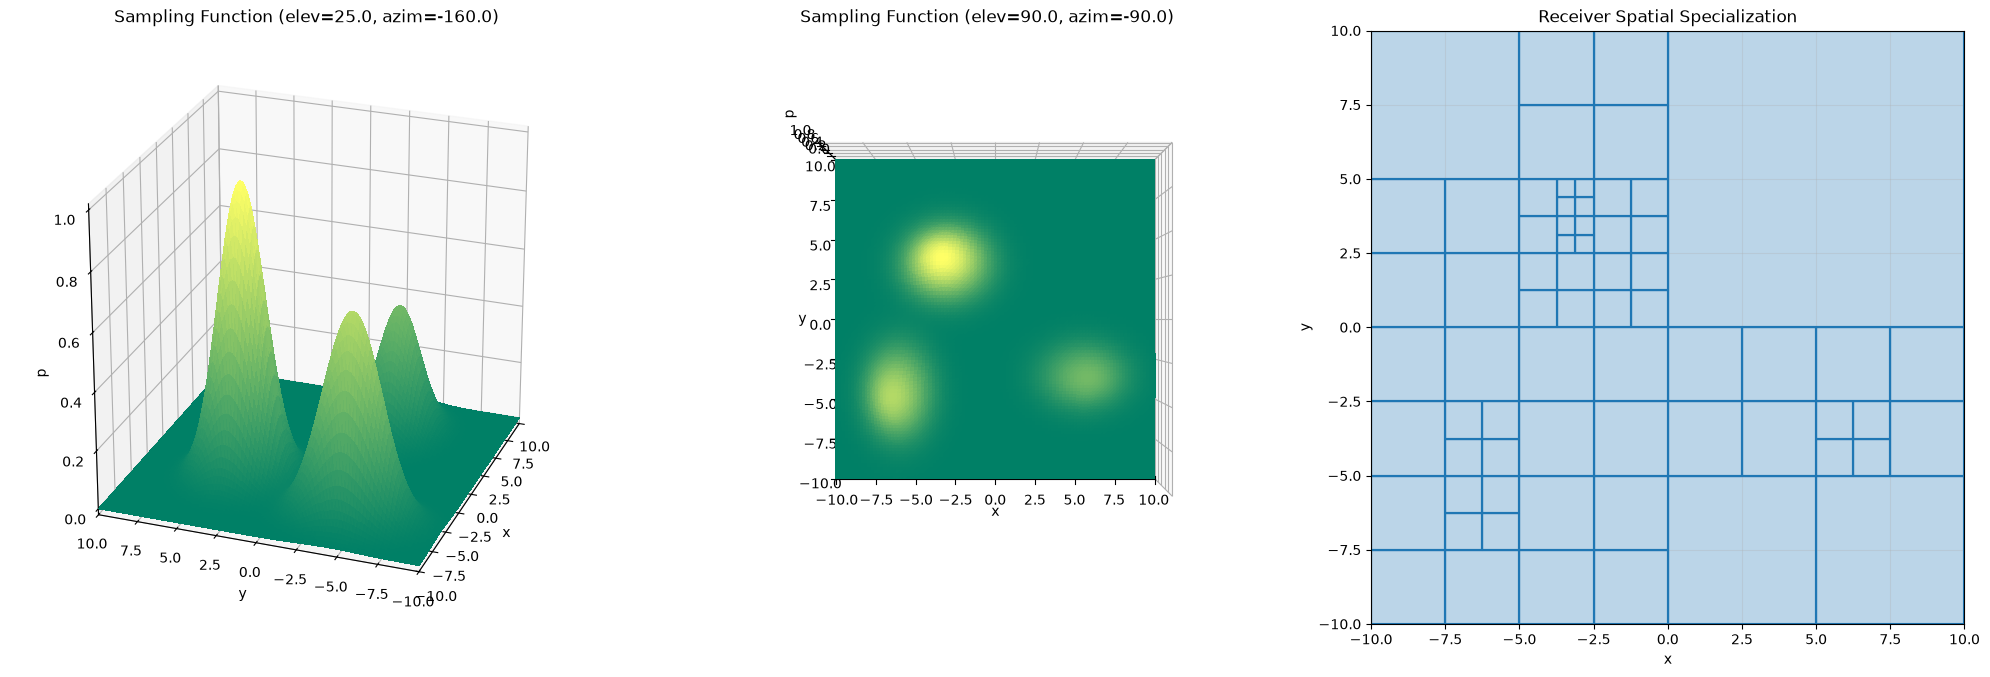

In [12]:
# approximate the sampling function maximum
max_p = get_sampling_function_max(sampling_function)

# initialize the random number generator
rng = random.Random(SEED)

# set the receiver plot steps
plot_steps = (
    {round(idx * (N_STEPS - 1) / (N_PLOTS - 1)) for idx in range(N_PLOTS)}
    if N_PLOTS > 1
    else {N_STEPS - 1}
)

# run simulation
for step in range(N_STEPS):
    print(f"Step {step + 1}/{N_STEPS}", end="\r")
    rsample = sample(sampling_function, max_p, rng)
    tsample = receiver.forward(rsample, bias=0.0)
    receiver.backward(rsample, tsample, feedback=0.0)
    # plot the receiver
    if step in plot_steps:
        fig = plt.figure(figsize=(20, 7))
        ax = [
            fig.add_subplot(1, 3, 1, projection="3d"),
            fig.add_subplot(1, 3, 2, projection="3d"),
            fig.add_subplot(1, 3, 3),
        ]
        plot_sampling_function(ax[0], sampling_function, elev=25.0, azim=-160.0)
        plot_sampling_function(ax[1], sampling_function, elev=90.0, azim=-90.0)
        plot_receiver(ax[2], receiver)
        # adjust the aspect ratio of each plot
        for axis in ax[:2]:
            axis.set_box_aspect((1, 1, 1), zoom=0.95)
        fig.tight_layout()
        plt.show()

## Conclusions

This playground provides an empirical view of how a two-dimensional `Receiver` adaptively specializes a continuous input space. It begins with a single region spanning the complete domain and receives only a sequence of input coordinates. From that interaction history, it progressively refines the spatial partition according to where stimuli occur.

Refinement is driven by visits. Regions that are encountered more frequently accumulate hits faster and therefore undergo more successive splits, producing smaller rectangles and finer spatial resolution. Less frequently visited regions remain comparatively coarse. In the reproduced run, this process produces the greatest specialization around the strongest peak of the sampling distribution, followed by the secondary and weaker peaks according to their relative frequency.

The resulting partition does not require prior knowledge of the input distribution. The `Receiver` observes only the coordinates presented to it, while the distribution of those observations determines where additional spatial resolution is created.

A standalone `Receiver` provides the input-side spatial specialization used by Jacinta. When combined with `Transmitter` inside `Processor`, each specialized input region provides a distinct context for output behavior. Examined in isolation, the module exhibits its intended behavior: it adaptively allocates finer spatial resolution to the regions of the input space that are encountered more frequently.